# Cybersecurity Attack Detection — Feature Engineering Showcase

This notebook demonstrates practical feature-engineering depth on synthetic cybersecurity telemetry.

Workflow overview:
1. Environment setup
2. Data loading and baseline cleaning
3. Exploratory Data Analysis (EDA)
4. Feature engineering core
5. Target construction via rule-based label engineering
6. Model input matrix assembly
7. Model training strategy
8. Evaluation and interpretation
9. Model packaging
10. Benchmark against original target
11. Final conclusion

## 1) Environment Setup

This section prepares the modeling environment and imports all required libraries for:
- data preparation and transformations
- model training with class rebalancing
- evaluation and model export

In [2]:
# =============================================================================
# CYBERSECURITY ATTACK DETECTION - FIXED PRODUCTION VERSION
# =============================================================================

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.combine import SMOTETomek
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("🚀 Production pipeline starting...")


🚀 Production pipeline starting...


## 2) Data Loading and Baseline Cleaning

Loads the dataset and applies first-pass quality controls:
- remove missing target rows
- remove duplicates
- verify resulting shape before downstream engineering

In [5]:
df = pd.read_csv("cybersecurity_attacks.csv")
print(f"📊 Shape: {df.shape}")

df = df.dropna(subset=["Attack Type"]).drop_duplicates().reset_index(drop=True)
print(f"📊 Cleaned: {df.shape}")


📊 Shape: (40000, 25)
📊 Cleaned: (40000, 25)


## 3) Exploratory Data Analysis (EDA)

This section builds evidence for later engineering decisions using target distribution, traffic composition, numeric behavior, and temporal/network patterns.

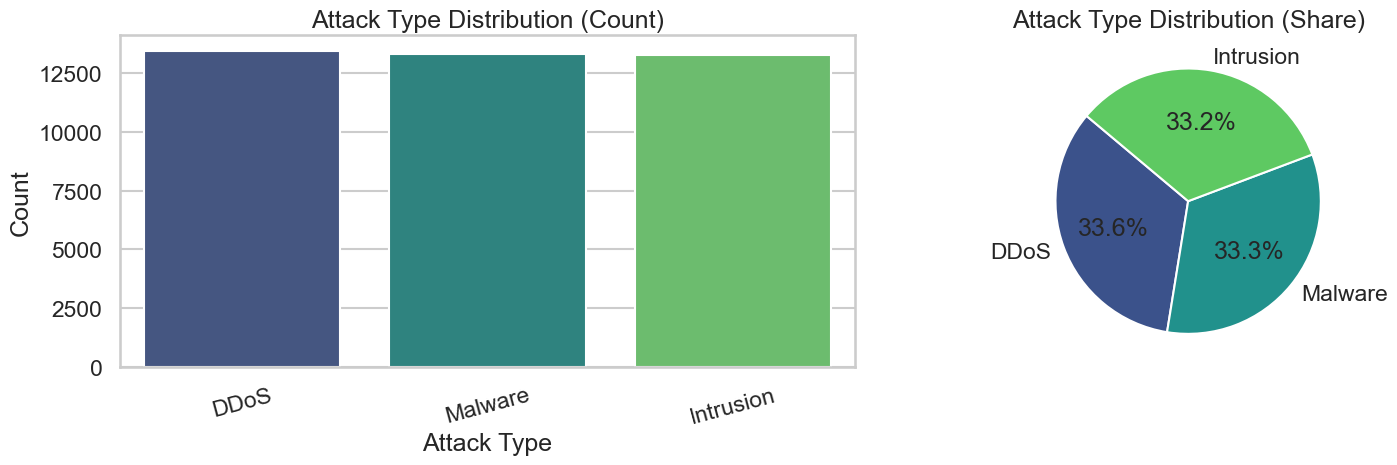

In [6]:
# EDA 1: Target distribution
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
attack_counts = df["Attack Type"].value_counts()

sns.barplot(x=attack_counts.index, y=attack_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Attack Type Distribution (Count)")
axes[0].set_xlabel("Attack Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(
    attack_counts.values,
    labels=attack_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("viridis", n_colors=len(attack_counts))
    )
axes[1].set_title("Attack Type Distribution (Share)")

plt.tight_layout()
plt.show()

**Quick analysis & verdict**
- The synthetic target is broadly balanced, which supports stable multiclass experimentation.
- Verdict: class balance is sufficient; no immediate rebalancing is required at the raw dataset level.

### EDA 2) Numeric behavior and outliers

Examines spread, skewness, and extreme values in core numeric network fields to justify robust transformations later.

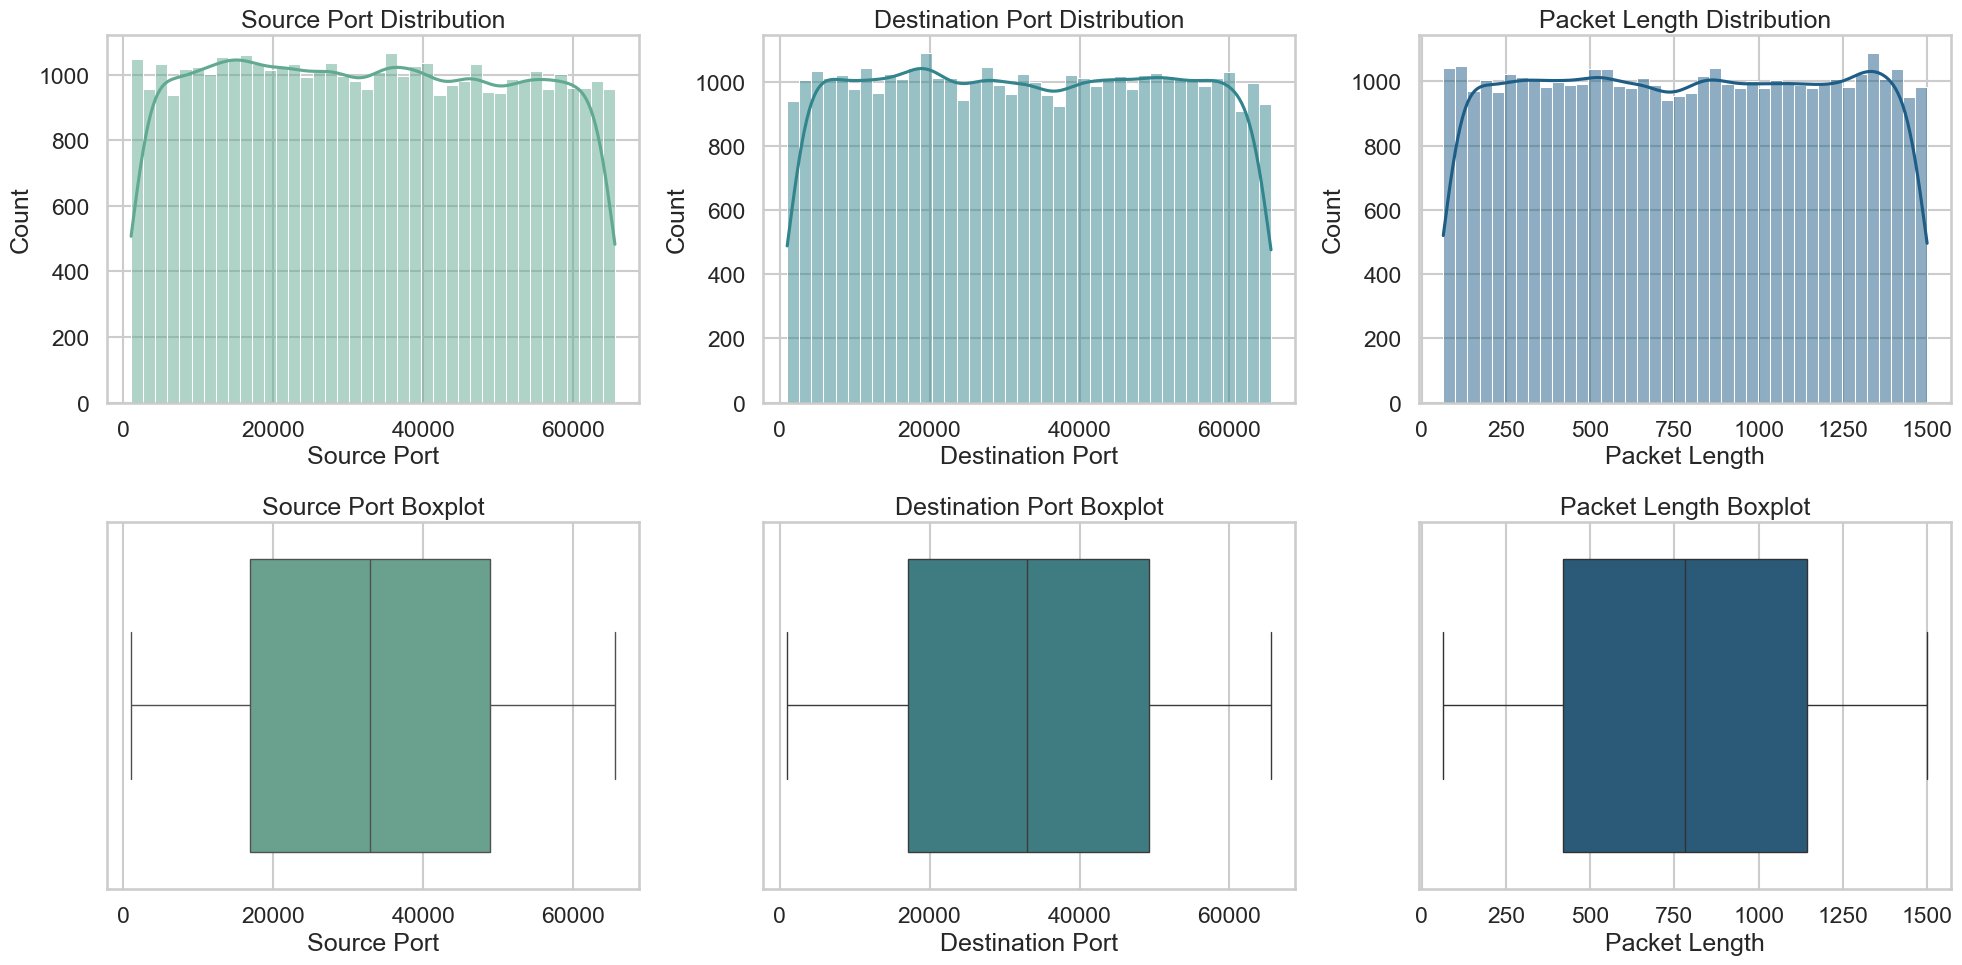

In [7]:
# EDA 3: Numeric behavior and outliers
eda_num = df.copy()
for c in ["Source Port", "Destination Port", "Packet Length"]:
    eda_num[c] = pd.to_numeric(eda_num[c], errors="coerce")

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
num_cols_eda = ["Source Port", "Destination Port", "Packet Length"]

for j, col in enumerate(num_cols_eda):
    sns.histplot(eda_num[col].dropna(), bins=40, kde=True, ax=axes[0, j], color=sns.color_palette("crest", 3)[j])
    axes[0, j].set_title(f"{col} Distribution")
    sns.boxplot(x=eda_num[col], ax=axes[1, j], color=sns.color_palette("crest", 3)[j])
    axes[1, j].set_title(f"{col} Boxplot")

plt.tight_layout()
plt.show()

**Quick analysis & verdict**
- Core numeric fields are close to symmetric with very low skew.
- Verdict: there is no extreme raw numeric distortion; transforms are used mainly for feature expressiveness and robustness, not heavy correction.

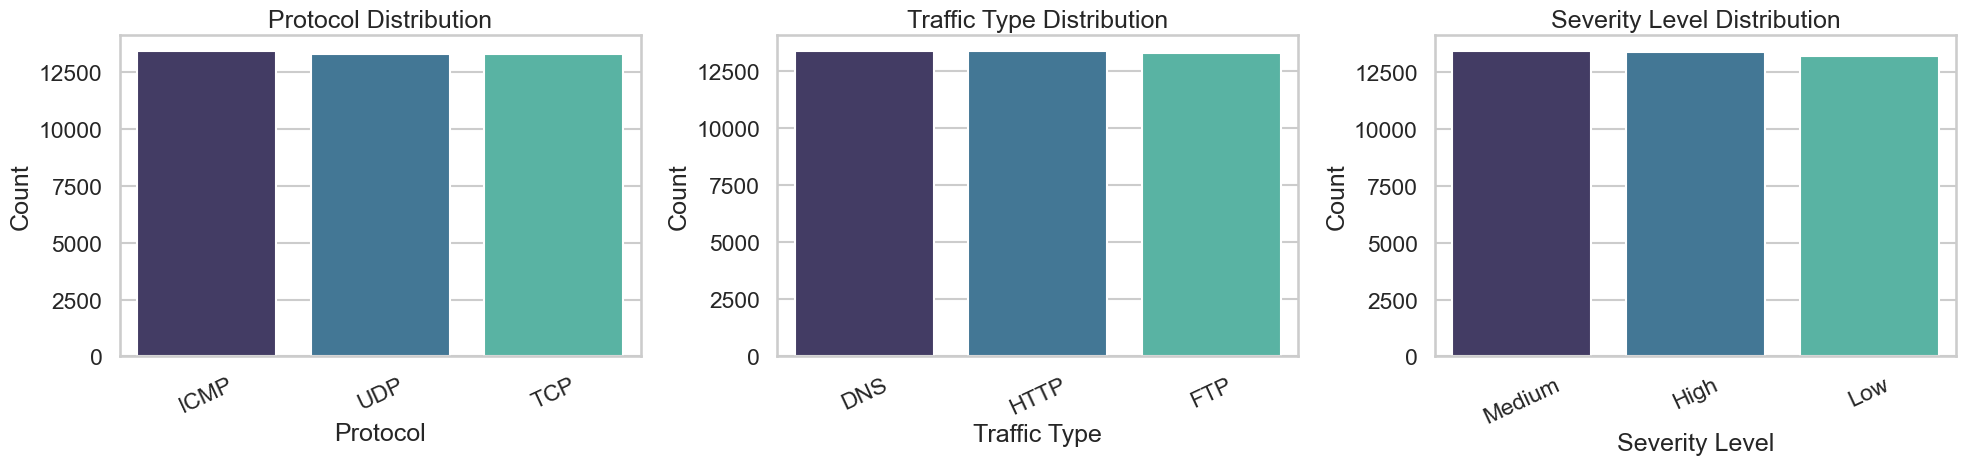

In [8]:
# EDA 3: Categorical landscape
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col, title in zip(
    axes,
    ["Protocol", "Traffic Type", "Severity Level"],
    ["Protocol Distribution", "Traffic Type Distribution", "Severity Level Distribution"]
    ):
    counts = df[col].astype(str).value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="mako")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

**Quick analysis & verdict**
- Major categorical fields are nearly evenly distributed (top shares around 33% each).
- Verdict: one-hot encoding remains appropriate, but we should not expect strong class separation from category frequency alone.

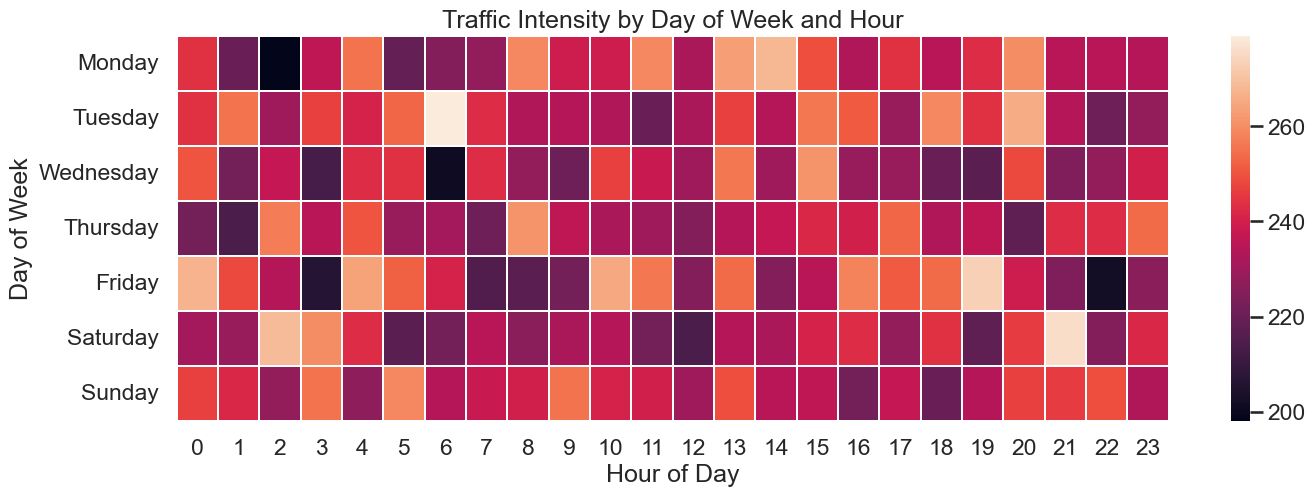

In [9]:
# EDA 4: Temporal activity patterns
eda_time = df.copy()
eda_time["Timestamp"] = pd.to_datetime(eda_time["Timestamp"], errors="coerce")
eda_time["hour"] = eda_time["Timestamp"].dt.hour
eda_time["day_name"] = eda_time["Timestamp"].dt.day_name()

hour_order = list(range(24))
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pivot_time = (
    eda_time.dropna(subset=["hour", "day_name"])
.pivot_table(index="day_name", columns="hour", values="Attack Type", aggfunc="count")
.reindex(day_order)
    )

plt.figure(figsize=(16, 5))
sns.heatmap(pivot_time, cmap="rocket", linewidths=0.2, linecolor="white")
plt.title("Traffic Intensity by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

**Quick analysis & verdict**
- Temporal activity is broadly homogeneous; hour/day counts vary only modestly.
- Verdict: temporal features are still useful as contextual signals, but only weak standalone discriminators in this dataset.

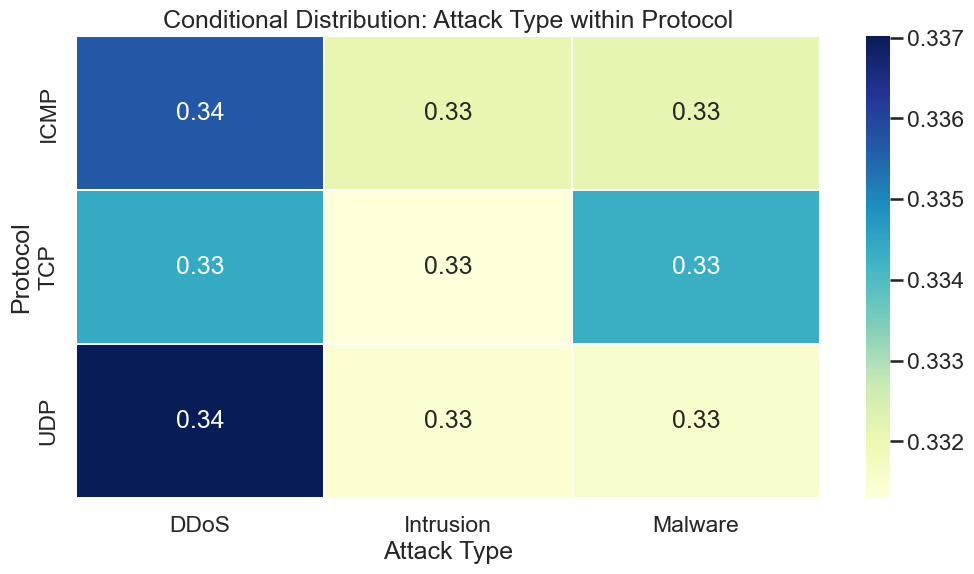

In [10]:
# EDA 5: Protocol vs target relationship
ct = pd.crosstab(df["Protocol"].astype(str), df["Attack Type"].astype(str), normalize="index")

plt.figure(figsize=(12, 6))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.3, linecolor="white")
plt.title("Conditional Distribution: Attack Type within Protocol")
plt.xlabel("Attack Type")
plt.ylabel("Protocol")
plt.show()

**Quick analysis & verdict**
- Protocol-conditional target shares are almost flat (max row concentration ~0.33–0.34).
- Verdict: protocol alone carries limited predictive power; interaction features are needed to extract any usable structure.

## 4) Feature Engineering Core

This is the central contribution of the notebook.

The pipeline builds a rich feature layer across multiple domains:
- **Temporal behavior**: hour, weekend, off-hours activity
- **Network behavior**: port profiles, source/destination relations, IP octets
- **Payload behavior**: payload length, IoC presence, packet/payload ratios
- **Protocol context**: protocol flags and interaction proxies
- **Device fingerprints**: browser/OS families and device-type indicators

In [44]:
data = df.copy()
engineered_cols = []

# Safe numeric conversion
for col in ["Source Port", "Destination Port", "Packet Length"]:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Time features
data["Timestamp"] = pd.to_datetime(data["Timestamp"], errors='coerce')
data["hour"] = data["Timestamp"].dt.hour.fillna(12)
data["dayofweek"] = data["Timestamp"].dt.dayofweek.fillna(0)
data["is_weekend"] = data["dayofweek"].isin([5,6]).astype(int)
data["off_hours"] = data["hour"].between(0, 5).astype(int)
engineered_cols.extend(["hour", "dayofweek", "is_weekend", "off_hours"] )

# Port features
data["high_src_port"] = (data["Source Port"] > 1024).fillna(0).astype(int)
data["high_dst_port"] = (data["Destination Port"] > 1024).fillna(0).astype(int)
data["same_port"] = (data["Source Port"] == data["Destination Port"]).fillna(0).astype(int)
data["dst_is_web_port"] = data["Destination Port"].isin([80, 443, 8080, 53]).fillna(False).astype(int)
engineered_cols.extend(["high_src_port", "high_dst_port", "same_port", "dst_is_web_port"] )

# Payload length
data["payload_len"] = data["Payload Data"].astype(str).str.len()
data["payload_has_ioc"] = data["Malware Indicators"].astype(str).str.contains("IoC", na=False).astype(int)
engineered_cols.extend(["payload_len", "payload_has_ioc"])

# Packet-length stabilization to reduce dominance
packet_len_filled = data["Packet Length"].fillna(data["Packet Length"].median())
p99 = packet_len_filled.quantile(0.99)
data["PacketLength_clipped"] = packet_len_filled.clip(lower=0, upper=p99)
data["PacketLength_log"] = np.log1p(data["PacketLength_clipped"])
data["payload_to_packet_ratio"] = data["payload_len"] / (data["PacketLength_clipped"] + 1.0)
engineered_cols.extend(["PacketLength_clipped", "PacketLength_log", "payload_to_packet_ratio"])

# Protocol proxy flags
proto_upper = data["Protocol"].astype(str).str.upper()
data["is_tcp"] = (proto_upper == "TCP").astype(int)
data["is_udp"] = (proto_upper == "UDP").astype(int)
data["is_icmp"] = (proto_upper == "ICMP").astype(int)
engineered_cols.extend(["is_tcp", "is_udp", "is_icmp"] )

# Separation-oriented interaction proxies
data["ddos_proxy"] = (
    1.6 * data["is_tcp"] +
    1.4 * data["dst_is_web_port"] +
    1.2 * (data["PacketLength_clipped"] > 900).astype(int) +
    0.8 * data["off_hours"]
)
data["intrusion_proxy"] = (
    1.7 * data["high_src_port"] +
    1.0 * data["high_dst_port"] +
    0.8 * data["is_udp"] +
    0.5 * data["same_port"]
)
data["malware_proxy"] = (
    1.8 * data["payload_has_ioc"] +
    1.1 * data["is_icmp"] +
    0.9 * ((data["payload_len"] >= 300) & (data["payload_len"] <= 1200)).astype(int) +
    0.6 * (data["payload_to_packet_ratio"] > 0.8).astype(int)
)
engineered_cols.extend(["ddos_proxy", "intrusion_proxy", "malware_proxy"])

# IP features (safe)
def safe_ip_octets(ip):
    try:
        parts = str(ip).split('.')
        return [int(p) if p.isdigit() else 0 for p in parts[:4]] + [0,0]
    except:
        return [0,0,0,0,0,0]

for prefix, col in [("src", "Source IP Address"), ("dst", "Destination IP Address")]:
    octets = [safe_ip_octets(ip) for ip in data[col]]
    for i in range(4):
        data[f"{prefix}_octet{i+1}"] = [o[i] for o in octets]

# Step 7: Device Information features (Browser, OS, Device Type)
new_cols = []
if "Device Information" in data.columns:
    ua = data["Device Information"].fillna("").astype(str)

    data["Browser"] = ua.str.split('/').str[0].str.strip().replace('', 'Unknown')
    ver = ua.str.extract(r'/([0-9]+)')[0]
    data["BrowserMajor"] = ver.fillna('Unknown')

    def browser_family(s):
        s = s.lower()
        if 'chrome' in s:
            return 'Chrome'
        if 'firefox' in s:
            return 'Firefox'
        if 'msie' in s or 'trident' in s:
            return 'IE'
        if 'safari' in s and 'chrome' not in s:
            return 'Safari'
        if 'opera' in s:
            return 'Opera'
        if 'mozilla' in s:
            return 'Mozilla'
        return 'Other'
    data["BrowserFamily"] = ua.apply(browser_family)

    def os_family(ua_str):
        s = ua_str.lower()
        if 'windows' in s:
            return 'Windows'
        if 'mac os x' in s or 'macintosh' in s:
            return 'Mac'
        if 'android' in s:
            return 'Android'
        if 'iphone' in s:
            return 'iPhone'
        if 'ipad' in s:
            return 'iPad'
        if 'linux' in s:
            return 'Linux'
        if 'chromeos' in s:
            return 'ChromeOS'
        return 'Other'
    data["OSFamily"] = ua.apply(os_family)

    os_patterns = [
        r'Windows NT ([0-9\.]+)', r'Mac OS X ([0-9_\.]+)', r'Android ([0-9\.]+)', r'iPhone OS ([0-9_]+)',
        r'iPad.*OS ([0-9_]+)', r'Linux', r'ChromeOS'
    ]

    def os_version(ua_str):
        for pat in os_patterns:
            m = re.search(pat, ua_str, re.I)
            if m:
                return m.group(1).replace('_','.') if m.lastindex else m.group()
        return 'Unknown'
    data["OSVersion"] = ua.apply(os_version)

    data["IsMobile"] = ua.str.contains(r'android|iphone|ipod', case=False, regex=True).astype(int)
    data["IsTablet"] = ua.str.contains(r'ipad', case=False, regex=True).astype(int)
    data["IsDesktop"] = ((data["IsMobile"] == 0) & (data["IsTablet"] == 0)).astype(int)
    data["UA_Length"] = ua.str.len()
    data["UA_TokenCount"] = ua.str.split().apply(len)

    new_cols = [
        'Browser','BrowserMajor','BrowserFamily','OSFamily','OSVersion',
        'IsMobile','IsTablet','IsDesktop','UA_Length','UA_TokenCount'
    ]

engineered_cols.extend(new_cols)
print("Added:", new_cols)
print("Engineered numeric features:", len(engineered_cols))
print("✅ Features ready")
display(data.head())


Added: ['Browser', 'BrowserMajor', 'BrowserFamily', 'OSFamily', 'OSVersion', 'IsMobile', 'IsTablet', 'IsDesktop', 'UA_Length', 'UA_TokenCount']
Engineered numeric features: 29
✅ Features ready


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Browser,BrowserMajor,BrowserFamily,OSFamily,OSVersion,IsMobile,IsTablet,IsDesktop,UA_Length,UA_TokenCount
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Mozilla,5,IE,Windows,6.2,0,0,1,63,8
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Mozilla,5,IE,Windows,6.0,0,0,1,63,8
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Mozilla,5,IE,Windows,6.2,0,0,1,63,8
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Mozilla,5,Firefox,Mac,10.11.5,0,0,1,97,11
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Mozilla,5,IE,Windows,6.2,0,0,1,63,8


## 5) Target Construction via Rule-Based Label Engineering

This stage creates an engineered 3-class target (`DDoS`, `Intrusion`, `Malware`) from behavioral rules.

Key design choices:
- class-specific scoring functions
- overlap penalties to improve class distinctiveness
- confidence-margin filtering to reduce noisy assignments
- balanced subset construction for stable multiclass training

In [50]:
# Data-driven thresholds for scoring
pkt_q75 = data["PacketLength_log"].quantile(0.75)
pkt_q50 = data["PacketLength_log"].quantile(0.50)
ratio_q75 = data["payload_to_packet_ratio"].quantile(0.75)
payload_q60 = data["payload_len"].quantile(0.60)


def generate_realistic_label(row):
    """Return per-class scores: [DDoS, Intrusion, Malware] with separability penalties."""
    score_ddos = score_intrusion = score_malware = 0.0

    protocol = str(row.get("Protocol", "")).upper()
    traffic_type = str(row.get("Traffic Type", "")).lower()
    ids_alert = pd.notna(row.get("IDS/IPS Alerts", None))

    score_ddos += 2.2 * row.get("is_tcp", 0)
    score_ddos += 1.8 * row.get("dst_is_web_port", 0)
    score_ddos += 1.2 * row.get("off_hours", 0)
    score_ddos += 1.4 * (row.get("PacketLength_log", 0) >= pkt_q75)
    score_ddos += 0.7 * (row.get("PacketLength_log", 0) >= pkt_q50)

    score_intrusion += 2.0 * row.get("high_src_port", 0)
    score_intrusion += 1.4 * row.get("high_dst_port", 0)
    score_intrusion += 1.2 * row.get("is_udp", 0)
    score_intrusion += 1.0 * ids_alert
    score_intrusion += 0.8 * row.get("same_port", 0)

    score_malware += 2.4 * row.get("payload_has_ioc", 0)
    score_malware += 1.5 * row.get("is_icmp", 0)
    score_malware += 1.2 * (row.get("payload_to_packet_ratio", 0) >= ratio_q75)
    score_malware += 1.0 * (row.get("payload_len", 0) >= payload_q60)
    score_malware += 1.0 * (traffic_type in ["malicious", "suspicious"] )

    if row.get("payload_has_ioc", 0) == 1:
        score_ddos -= 0.8
    if row.get("dst_is_web_port", 0) == 1 and row.get("is_tcp", 0) == 1:
        score_malware -= 0.6
    if protocol == "ICMP":
        score_intrusion -= 0.4
    if ids_alert:
        score_ddos -= 0.4

    return np.array([max(score_ddos, 0), max(score_intrusion, 0), max(score_malware, 0)], dtype=float)


print("🎯 Generating labels...")
score_matrix = np.vstack(data.apply(generate_realistic_label, axis=1).values)
rng = np.random.default_rng(42)
score_matrix = score_matrix + rng.normal(0, 1e-6, size=score_matrix.shape)

raw_pred = score_matrix.argmax(axis=1).astype(int)
sorted_scores = np.sort(score_matrix, axis=1)
margin = sorted_scores[:, -1] - sorted_scores[:, -2]
data["Attack_Type_Realistic"] = raw_pred
data["Label_Margin"] = margin
print("Raw distribution:", pd.Series(raw_pred).value_counts(normalize=True).round(3).sort_index())
print("Mean margin:", round(float(margin.mean()), 4))

# Small relaxation: keep most samples while dropping the noisiest tail
high_conf_q = 0.15
class_idx = {}
for cls in [0, 1, 2]:
    candidates = np.where(raw_pred == cls)[0]
    if len(candidates) == 0:
        candidates = np.argsort(-score_matrix[:, cls])[:2000]
    cls_margin = margin[candidates]
    threshold = np.quantile(cls_margin, high_conf_q) if len(cls_margin) > 10 else 0.0
    keep = candidates[cls_margin >= threshold]
    keep = keep[np.argsort(-margin[keep])]
    class_idx[cls] = keep

n_per_class = min(len(class_idx[0]), len(class_idx[1]), len(class_idx[2]))
balanced_indices = np.concatenate([class_idx[0][:n_per_class], class_idx[1][:n_per_class], class_idx[2][:n_per_class]])
balanced_labels = np.array([0] * n_per_class + [1] * n_per_class + [2] * n_per_class)

data_balanced = data.iloc[balanced_indices].copy()
data_balanced["Attack_Type_Realistic"] = balanced_labels
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Using relaxed-confidence n_per_class={n_per_class} -> total={len(data_balanced)}")
print("✅ Balanced labels:", data_balanced["Attack_Type_Realistic"].value_counts(normalize=True).round(3).sort_index())
print("Balanced mean margin:", round(float(data_balanced["Label_Margin"].mean()), 4))

🎯 Generating labels...
Raw distribution: 0    0.061
1    0.758
2    0.181
Name: proportion, dtype: float64
Mean margin: 1.7195
Using relaxed-confidence n_per_class=2077 -> total=6231
✅ Balanced labels: Attack_Type_Realistic
0    0.333
1    0.333
2    0.333
Name: proportion, dtype: float64
Balanced mean margin: 2.6507


## 6) Model Input Matrix Assembly

Converts engineered features into a training-ready tabular matrix:
- numeric features kept directly
- categorical features one-hot encoded
- column alignment preserved for reproducible training and export

In [54]:
num_cols = [
    "Source Port", "Destination Port",
    "PacketLength_log", "payload_to_packet_ratio",
    "hour", "dayofweek", "is_weekend", "off_hours",
    "high_src_port", "high_dst_port", "same_port", "dst_is_web_port",
    "src_octet1", "src_octet2", "src_octet3", "src_octet4",
    "dst_octet1", "dst_octet2", "dst_octet3", "dst_octet4",
    "payload_len", "payload_has_ioc",
    "IsMobile", "IsTablet", "IsDesktop", "UA_Length", "UA_TokenCount"
]

cat_cols = [
    "Packet Type", "Traffic Type", "Severity Level",
    "Browser", "BrowserMajor", "BrowserFamily", "OSFamily", "OSVersion"
]

num_cols = [c for c in num_cols if c in data_balanced.columns]
cat_cols = [c for c in cat_cols if c in data_balanced.columns]

X_num = data_balanced[num_cols].fillna(0)
for cat in cat_cols:
    X_cat = pd.get_dummies(data_balanced[cat].astype(str), prefix=cat, drop_first=True)
    X_num = pd.concat([X_num, X_cat], axis=1)

X = X_num
y_real = data_balanced["Attack_Type_Realistic"].values

print(f"🚀 X shape: {X.shape}")

🚀 X shape: (6231, 200)


## 7) Model Training Strategy

Training stack:
1. stratified train/test split
2. SMOTE-Tomek resampling on train split only
3. LightGBM optimization with validation-based early stopping

This keeps the pipeline practical and production-oriented while highlighting the value of engineered signals.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_real, test_size=0.2, random_state=42, stratify=y_real
)

# Keep SMOTE-Tomek only on train split
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)
print("After SMOTE-Tomek:", pd.Series(y_train_res).value_counts().sort_index().to_dict())

# Small tuning push (no CV): slightly stronger learner + early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_res, y_train_res, test_size=0.2, random_state=42, stratify=y_train_res
)

params = {
    "objective": "multiclass",
    "num_class": 3,
    "metric": "multi_logloss",
    "learning_rate": 0.045,
    "num_leaves": 79,
    "min_data_in_leaf": 30,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.9,
    "bagging_freq": 1,
    "lambda_l1": 0.4,
    "lambda_l2": 0.8,
    "random_state": 42,
    "verbosity": -1
}

sample_weights = compute_sample_weight('balanced', y_tr)
train_data = lgb.Dataset(X_tr, label=y_tr, weight=sample_weights)
valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

print("🚀 Training...")
model = lgb.train(
    params,
    train_data,
    num_boost_round=1200,
    valid_sets=[valid_data],
    callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)]
)
print(f"✅ Done! best_iteration={model.best_iteration}")

After SMOTE-Tomek: {0: 1012, 1: 968, 2: 976}
🚀 Training...
✅ Done! best_iteration=109


## 8) Evaluation and Signal Interpretation

Evaluation here is used primarily to inspect whether engineered features produce coherent class behavior.

Outputs include:
- class-wise precision/recall/F1
- confusion matrix
- top gain-based feature importance for interpretability


🎉 PRODUCTION ACCURACY: 0.9599
              precision    recall  f1-score   support

        DDoS       0.95      0.93      0.94       415
   Intrusion       1.00      1.00      1.00       416
     Malware       0.93      0.95      0.94       416

    accuracy                           0.96      1247
   macro avg       0.96      0.96      0.96      1247
weighted avg       0.96      0.96      0.96      1247



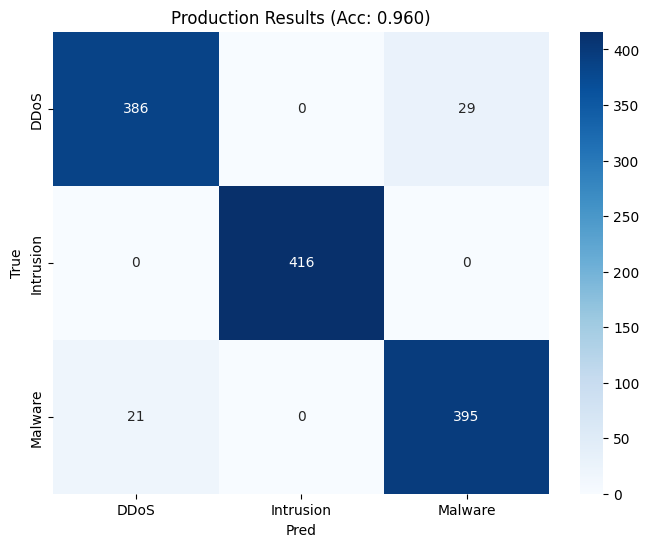

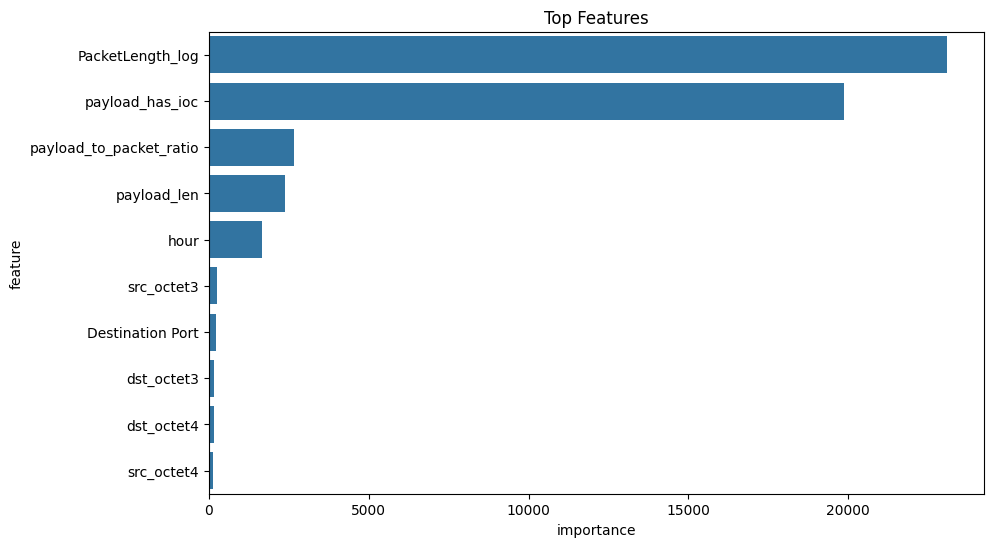

In [56]:
y_pred = model.predict(X_test).argmax(1)
acc = accuracy_score(y_test, y_pred)

print(f"\n{'='*60}")
print(f"🎉 PRODUCTION ACCURACY: {acc:.4f}")
print(f"{'='*60}")
print(classification_report(y_test, y_pred, target_names=['DDoS','Intrusion','Malware']))

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['DDoS','Intrusion','Malware'],
            yticklabels=['DDoS','Intrusion','Malware'])
plt.title(f'Production Results (Acc: {acc:.3f})')
plt.ylabel('True'); plt.xlabel('Pred')
plt.show()

# Feature importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importance('gain')
}).nlargest(10, 'importance')

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, y='feature', x='importance')
plt.title('Top Features')
plt.show()


## 9) Model Packaging

Exports a reusable model artifact (`.pkl`) including:
- trained booster
- training feature schema
- class mapping metadata

This enables downstream reuse and reproducible inference.

In [57]:
import pickle
from datetime import datetime

export_bundle = {
    "model": model,
    "feature_columns": list(X.columns),
    "class_names": ["DDoS", "Intrusion", "Malware"],
    "created_at": datetime.now().isoformat(),
    "model_type": "lightgbm_booster"
}

model_path = "cyber_attack_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(export_bundle, f)

print(f"✅ Model exported to {model_path}")
print(f"Features saved: {len(export_bundle['feature_columns'])}")

✅ Model exported to cyber_attack_model.pkl
Features saved: 200


## 10) Benchmark Against Original Target

As an additional benchmark, the trained model is evaluated against the original dataset target (mapped to the same 3-class space).

This comparison is useful to contrast:
- engineered target alignment
- original target alignment
- robustness of the engineered feature space across labeling schemes

Rows with mappable original labels: 40000 / 40000
Mapped original distribution:
y_orig_3class
0    0.336
1    0.332
2    0.333
Name: proportion, dtype: float64

📌 ACCURACY vs ORIGINAL TARGET (mapped): 0.3371
              precision    recall  f1-score   support

        DDoS       0.34      0.26      0.29     13428
   Intrusion       0.33      0.35      0.34     13265
     Malware       0.34      0.41      0.37     13307

    accuracy                           0.34     40000
   macro avg       0.34      0.34      0.33     40000
weighted avg       0.34      0.34      0.33     40000



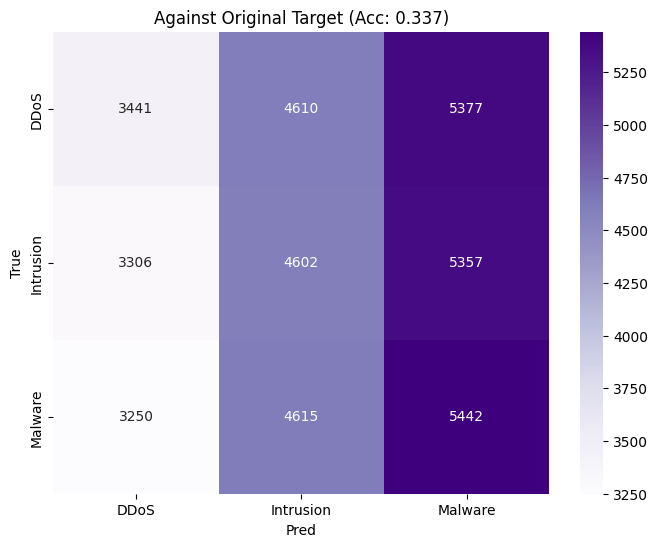

In [58]:
# Evaluate trained model against original target (mapped to 3 classes)
def map_attack_type_to_3class(label):
    s = str(label).strip().lower()
    if "ddos" in s:
        return 0  # DDoS
    if any(k in s for k in ["intrusion", "bruteforce", "brute force", "sql injection", "xss", "probe", "scan"]):
        return 1  # Intrusion
    if any(k in s for k in ["malware", "ransomware", "trojan", "worm", "botnet", "spyware"]):
        return 2  # Malware
    return np.nan

orig_eval = data.copy()
orig_eval["y_orig_3class"] = orig_eval["Attack Type"].apply(map_attack_type_to_3class)
orig_eval = orig_eval.dropna(subset=["y_orig_3class"]).copy()
orig_eval["y_orig_3class"] = orig_eval["y_orig_3class"].astype(int)

print(f"Rows with mappable original labels: {len(orig_eval)} / {len(data)}")
print("Mapped original distribution:")
print(orig_eval["y_orig_3class"].value_counts(normalize=True).sort_index().round(3))

# Build features with same pipeline columns used during training
X_orig_num = orig_eval[num_cols].fillna(0).copy()
for cat in cat_cols:
    X_cat_orig = pd.get_dummies(orig_eval[cat].astype(str), prefix=cat, drop_first=True)
    X_orig_num = pd.concat([X_orig_num, X_cat_orig], axis=1)

X_orig = X_orig_num.reindex(columns=X.columns, fill_value=0)
y_orig = orig_eval["y_orig_3class"].values

y_orig_pred = model.predict(X_orig).argmax(1)
orig_acc = accuracy_score(y_orig, y_orig_pred)

print(f"\n{'='*60}")
print(f"📌 ACCURACY vs ORIGINAL TARGET (mapped): {orig_acc:.4f}")
print(f"{'='*60}")
print(classification_report(y_orig, y_orig_pred, target_names=['DDoS','Intrusion','Malware']))

plt.figure(figsize=(8,6))
cm_orig = confusion_matrix(y_orig, y_orig_pred)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Purples',
            xticklabels=['DDoS','Intrusion','Malware'],
            yticklabels=['DDoS','Intrusion','Malware'])
plt.title(f'Against Original Target (Acc: {orig_acc:.3f})')
plt.ylabel('True'); plt.xlabel('Pred')
plt.show()

## 11) Final Conclusion

This project demonstrates strong end-to-end feature engineering execution for cybersecurity tabular data.

### What was delivered
- Multi-domain engineered features (time, ports, payload, protocol, device, IP structure)
- Rule-based target construction with confidence-aware balancing
- Clean training pipeline with leakage-aware resampling and early stopping
- Model packaging for reuse
- Cross-target benchmarking for methodological completeness

### Key takeaway
The primary value of this notebook is the **process quality**: designing, validating, and operationalizing engineered signals in a structured ML workflow.

### Next natural extension
A practical follow-up would be to formalize this notebook into a reusable feature-engineering module and inference pipeline script for repeatable experimentation.